In [ ]:
!nvidia-smi

Mon Dec  1 18:15:32 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [2]:
!pip install ultralytics albumentations roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 61.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [3]:
from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.3/112.6 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

In [7]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets


from roboflow import Roboflow
rf = Roboflow(api_key="ispXgZg4Pex6XsfbblJq")
project = rf.workspace("image-classification-sipfa").project("object-detection-pl1yk")
version = project.version(2)
dataset = version.download("yolov12")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Object-Detection-2 in yolov12:: 100%|██████████| 532/532 [00:00<00:00, 5713.80it/s]


In [8]:
%cd {HOME}

!yolo task=detect mode=train model=yolo12s.pt data={dataset.location}/data.yaml epochs=20 imgsz=800 plots=True

/content
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Object-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [36]:
import pandas as pd
%cd {HOME}
results_df = pd.read_csv(f'{HOME}/runs/detect/train/results.csv')
display(results_df)

/content


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,31.7546,1.67140,4.50979,2.18949,0.78389,0.78155,0.81787,0.31725,1.96301,5.77991,3.43262,0.000217,0.000217,0.000217
1,2,45.0777,1.35721,1.85654,1.75134,0.46537,0.81250,0.52341,0.34869,1.35905,83.59890,2.24708,0.000428,0.000428,0.000428
2,3,58.3802,1.42784,1.43286,1.80347,0.06065,0.13512,0.02843,0.01231,2.39438,25.93440,3.77023,0.000616,0.000616,0.000616
3,4,71.4998,1.44810,1.17356,1.80059,0.00039,0.02083,0.00013,0.00003,NaN,NaN,NaN,0.000781,0.000781,0.000781
4,5,84.6921,1.40645,1.01288,1.72801,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,0.000922,0.000922,0.000922
5,6,97.8577,1.32427,0.99866,1.71052,1.00000,0.07143,0.17654,0.06818,2.36891,20.36160,3.29678,0.001041,0.001041,0.001041
6,7,110.8140,1.32291,0.88960,1.69348,0.50274,0.02857,0.00090,0.00020,3.54498,95.37460,4.32820,0.001137,0.001137,0.001137
7,8,123.6900,1.25261,0.85910,1.62433,0.01628,0.58869,0.00938,0.00469,1.66490,inf,2.10514,0.001089,0.001089,0.001089
8,9,136.4930,1.25450,0.78101,1.60382,0.21534,0.90774,0.26112,0.10512,1.59445,77.13040,2.33061,0.001007,0.001007,0.001007
9,10,149.4950,1.17702,0.75572,1.58951,0.20408,0.36845,0.19598,0.06007,3.17689,3.44913,3.99294,0.000924,0.000924,0.000924


In [9]:
!ls {HOME}/runs/detect/train/

args.yaml			 labels.jpg	     train_batch1.jpg
BoxF1_curve.png			 results.csv	     train_batch2.jpg
BoxP_curve.png			 results.png	     val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg    val_batch0_pred.jpg
BoxR_curve.png			 train_batch140.jpg  weights
confusion_matrix_normalized.png  train_batch141.jpg
confusion_matrix.png		 train_batch142.jpg


/content


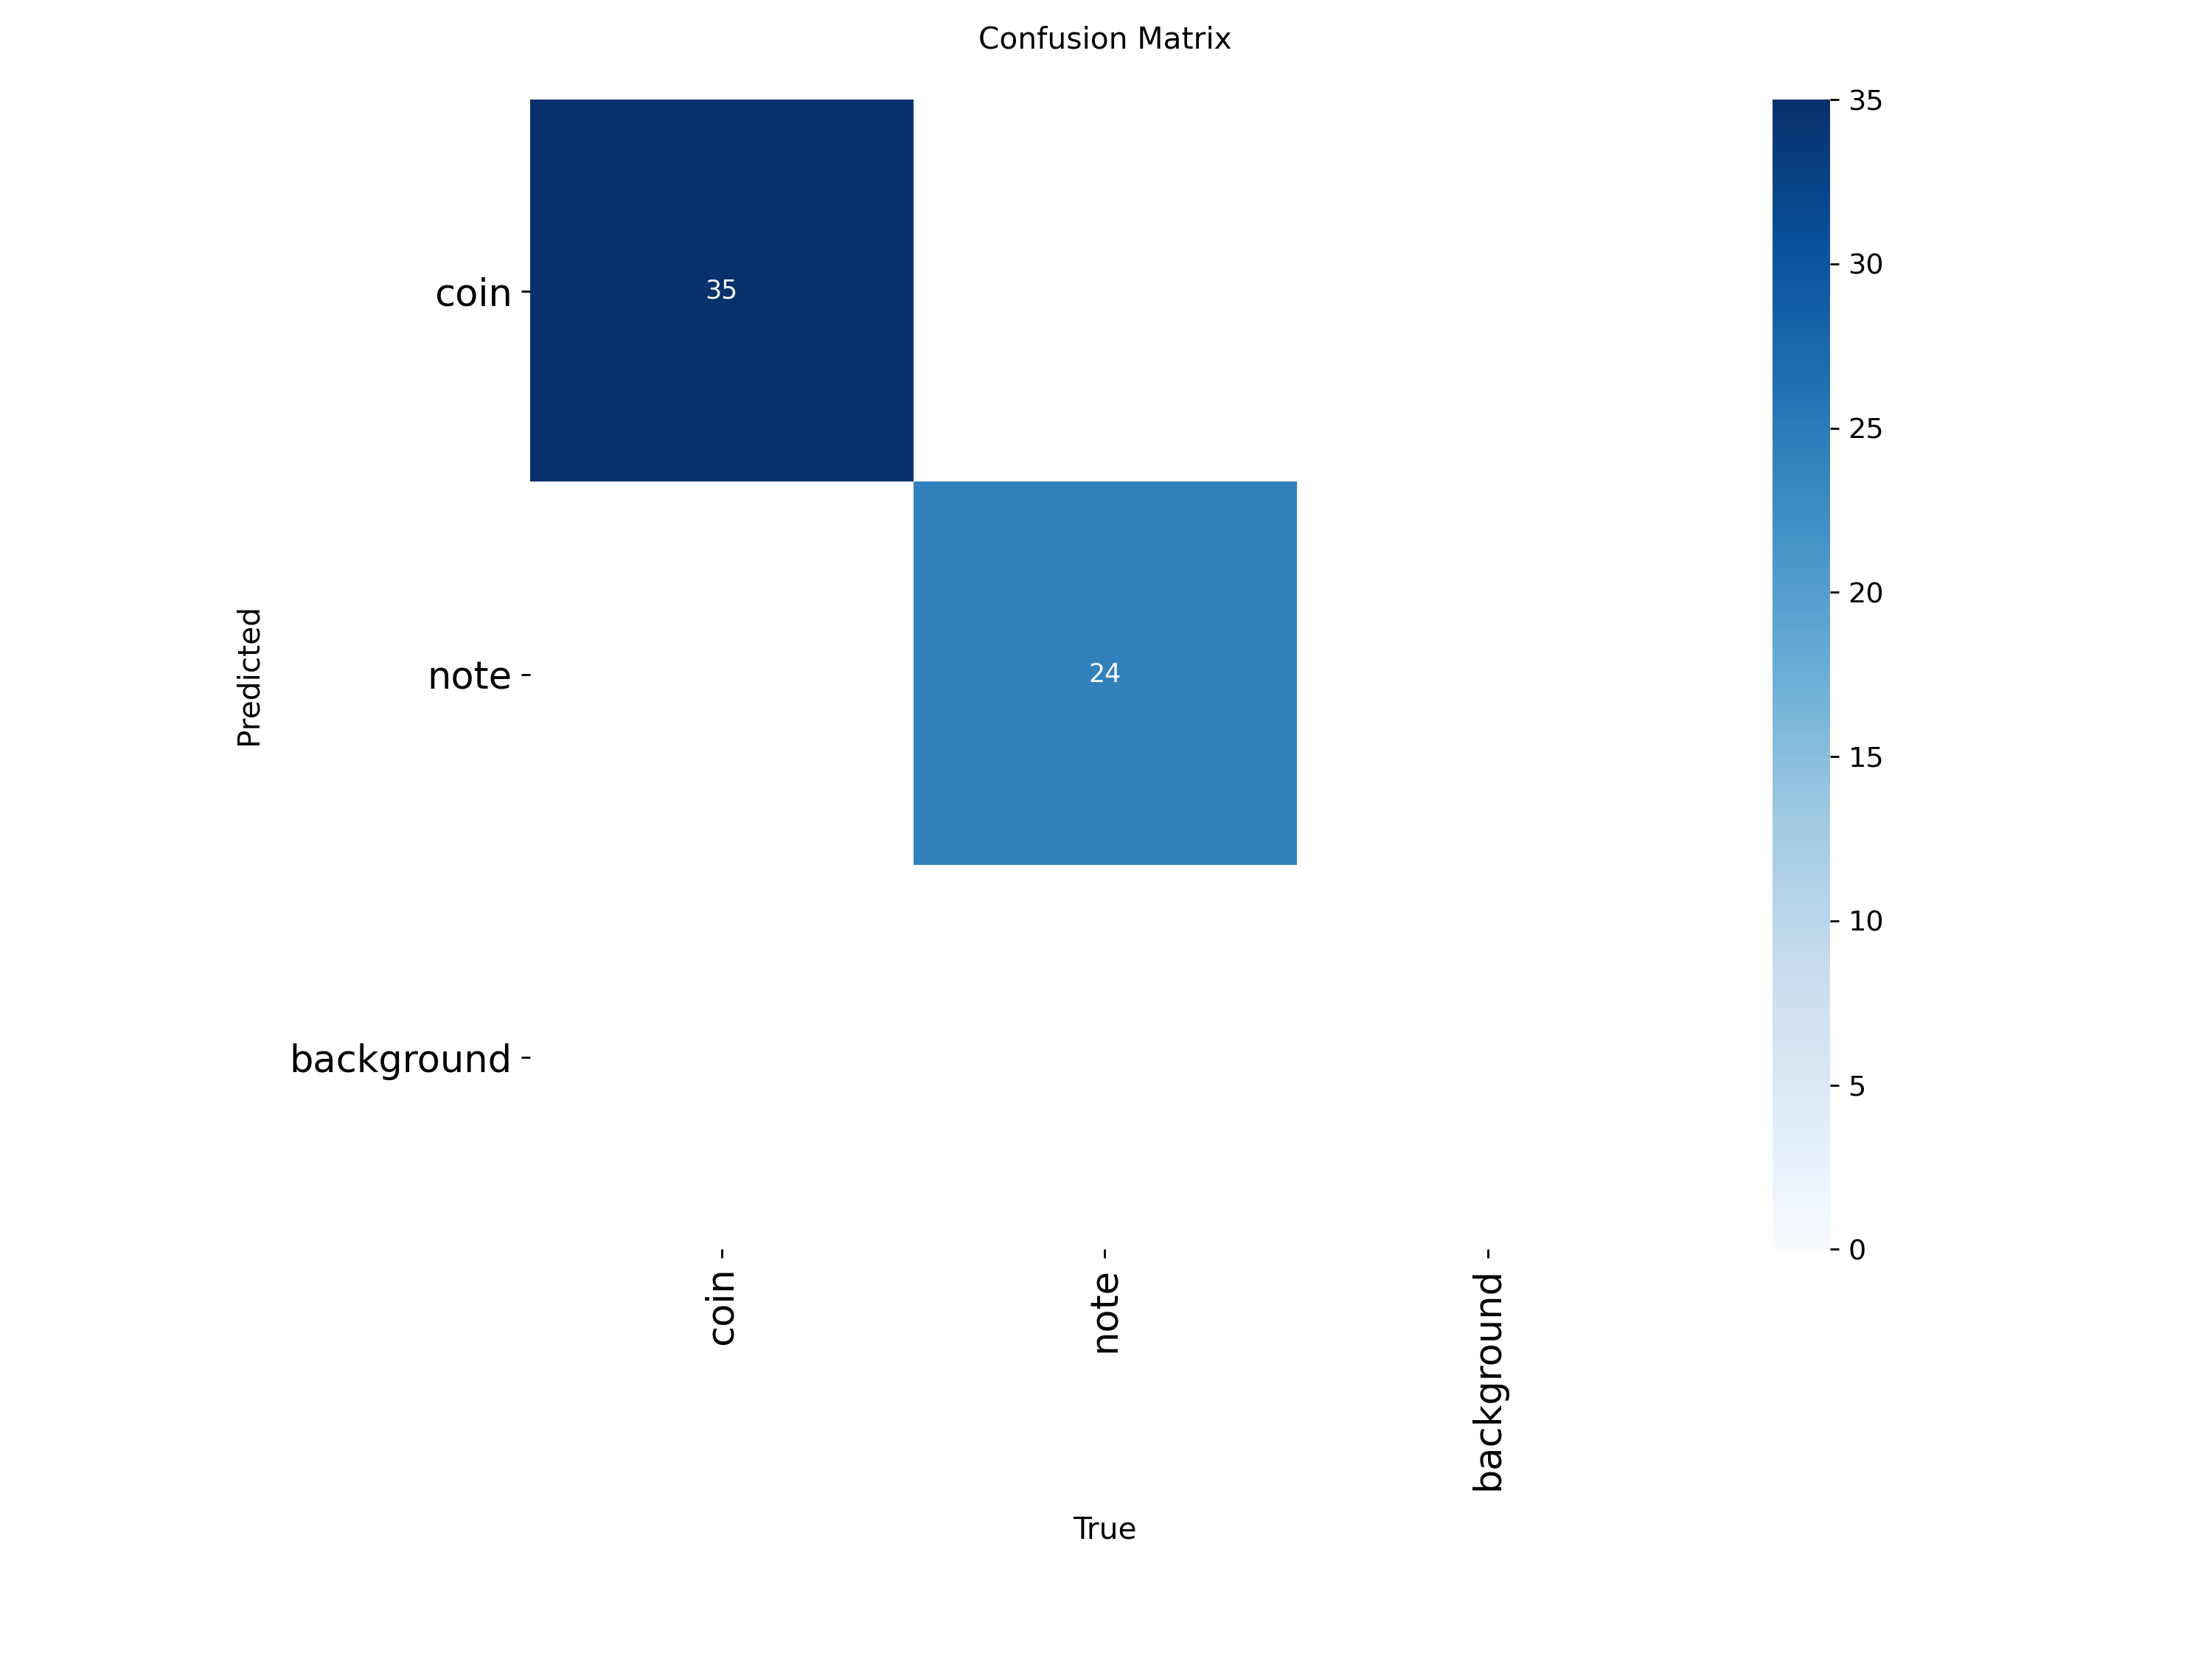

In [11]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=800)

/content


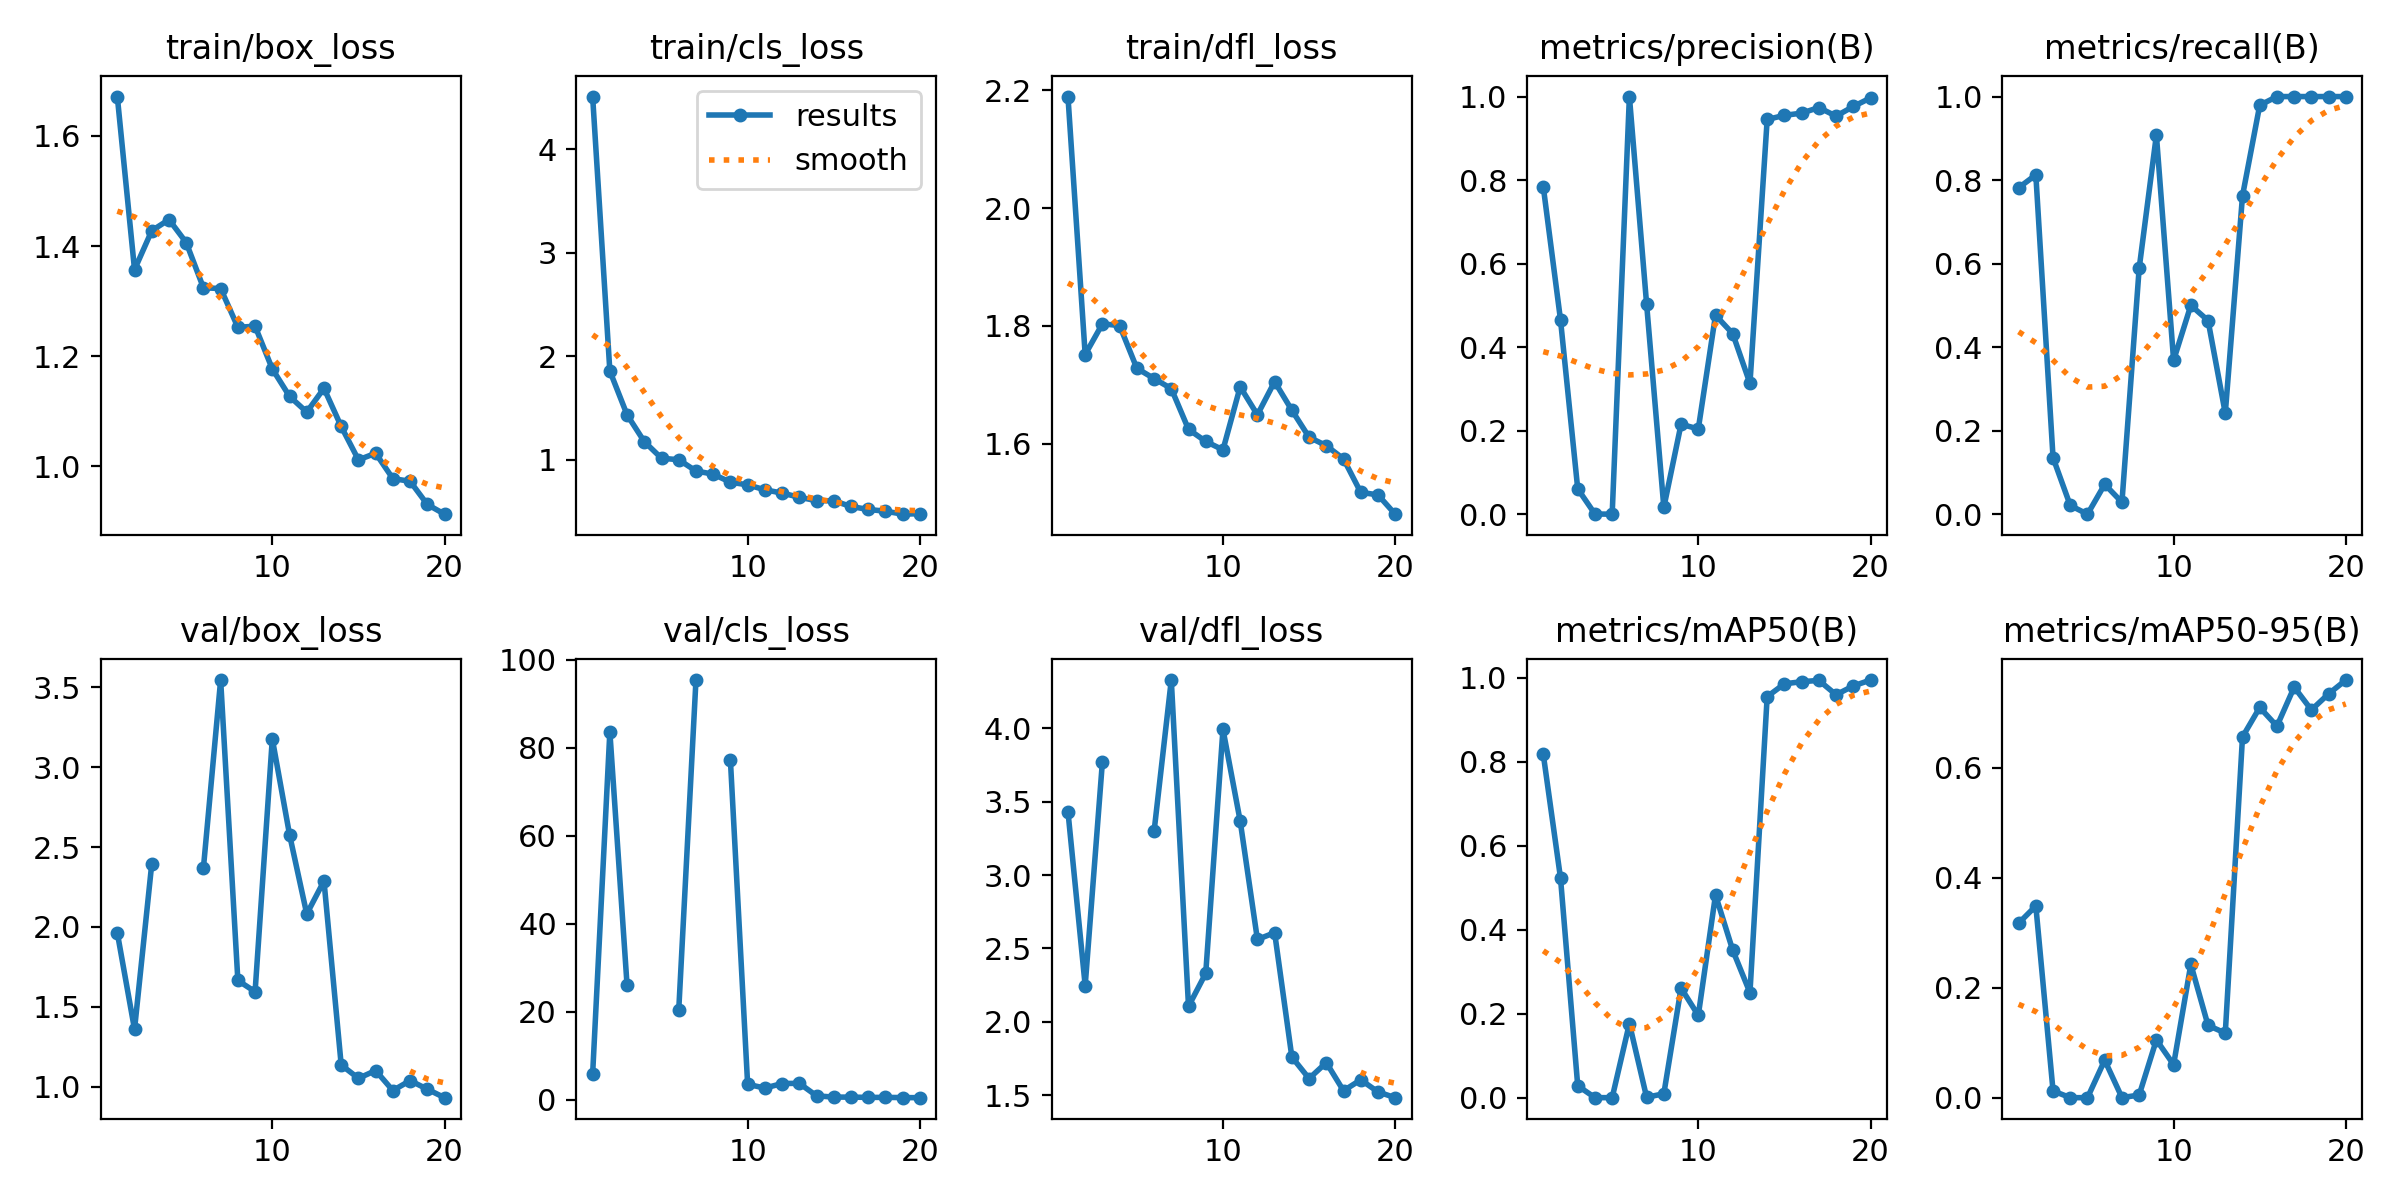

In [13]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=800)

/content


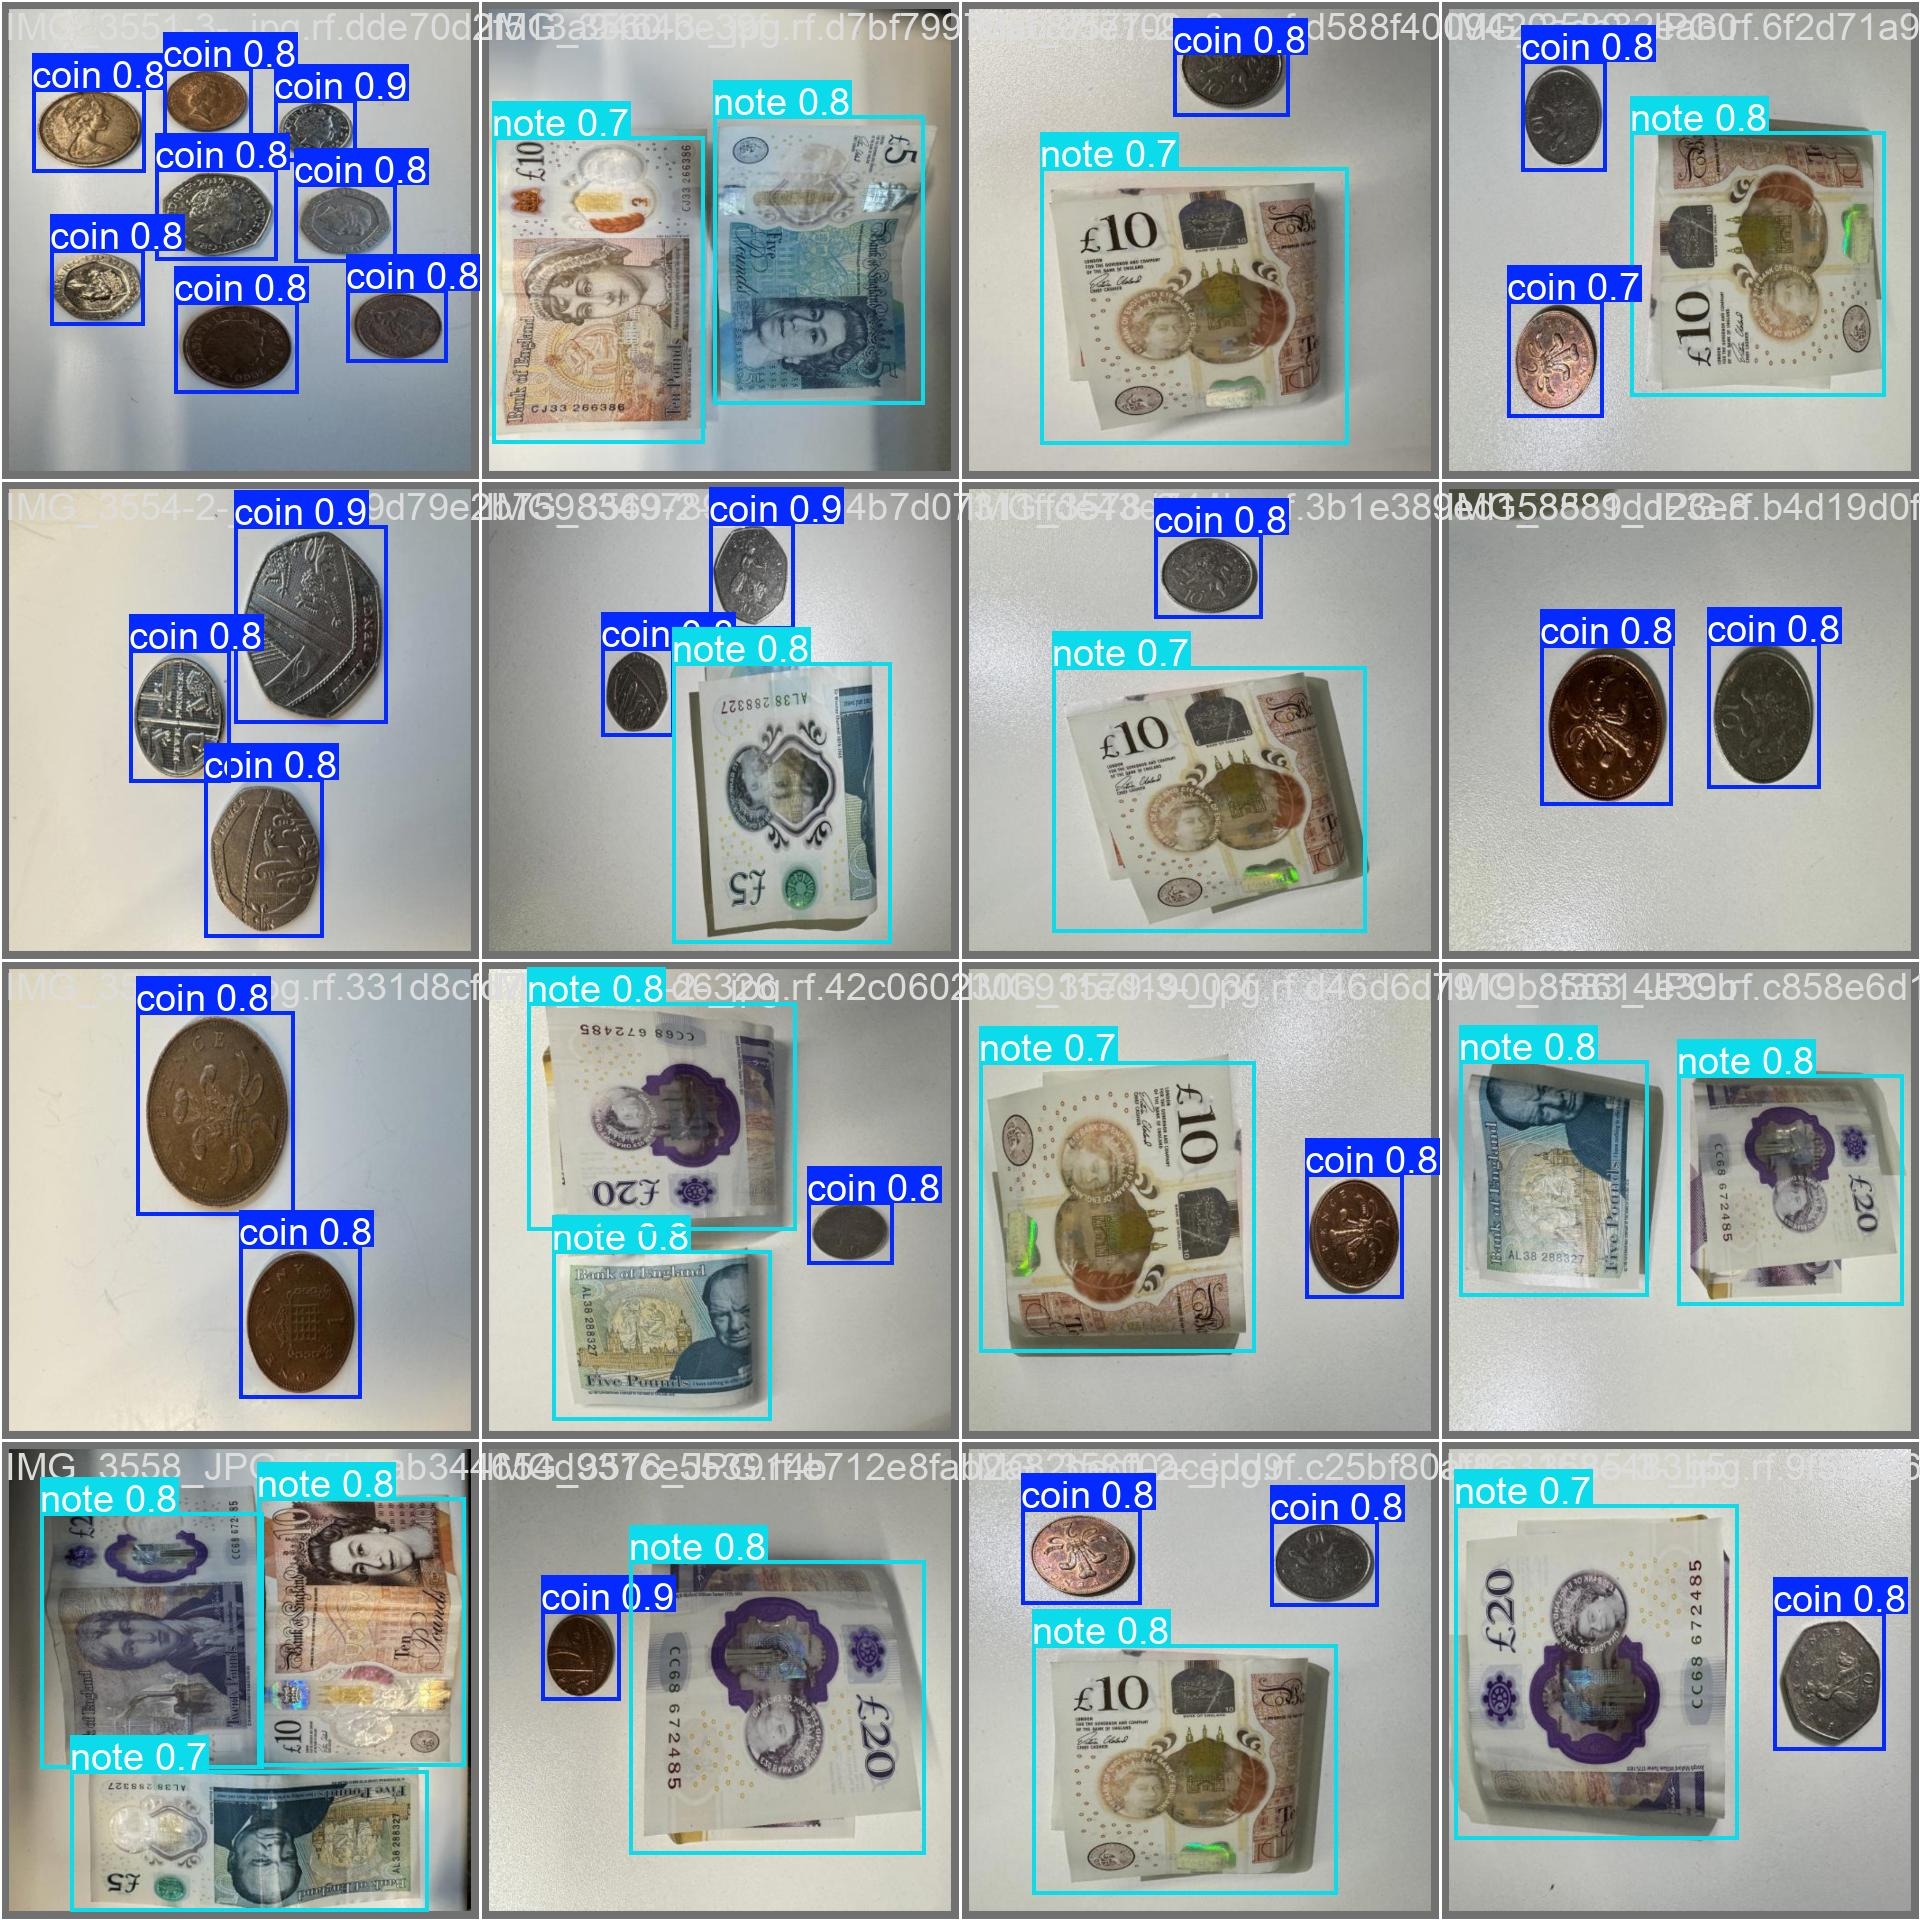

In [32]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=800)